# Baseline subtraction can break monotonicity in $g$

This notebook gives two explicit counterexamples to the following tempting construction. Start with a network output $p(t,g)$ that is increasing in time $t$ and decreasing in event index/threshold $g$, then impose the event-free baseline by defining

$$F(t,g)=p(t,g)-p(0,g).$$

The subtraction guarantees $F(0,g)=0$, and it preserves monotonicity in $t$. It does **not** generally preserve monotonicity in $g$, because

$$\frac{\partial F}{\partial g}(t,g)=\frac{\partial p}{\partial g}(t,g)-\frac{\partial p}{\partial g}(0,g),$$

whose sign is not fixed by requiring both terms to be non-positive.

The examples use a partially monotone min–max network: affine units have nonnegative $t$ coefficients and nonpositive $g$ coefficients, their outputs are combined using `min` and `max`, and a sigmoid maps the result into $(0,1)$. Min, max, and an increasing sigmoid all preserve the coordinate-wise monotonicity. This is the architecture family described by Daniels & Velikova (2010), *Monotone and Partially Monotone Neural Networks*, IEEE Transactions on Neural Networks 21(6), 906–917.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def minmax_surface(t, g, planes, blocks):
    """Sigmoid(max_k min_{j in block k} (a_j + b_j*t + c_j*g))."""
    values = np.stack([a + b * t + c * g for a, b, c in planes])
    block_values = np.stack([np.min(values[list(block)], axis=0) for block in blocks])
    return sigmoid(np.max(block_values, axis=0))

t = np.linspace(0.0, 1.0, 201)
g = np.linspace(0.0, 1.0, 201)
T, G = np.meshgrid(t, g, indexing="ij")

## Two monotone network surfaces

Every plane below is written as $a+bt+cg$, with $b\geq0$ and $c\leq0$.

- **Surface 1** is one `min` block containing two affine units. It is the smallest transparent example.
- **Surface 2** is a `max` of two `min` blocks, showing that the same issue occurs in a less degenerate min–max network.

These are fixed network weights, not fitted examples; consequently the counterexample is deterministic.

In [2]:
examples = {
    "Surface 1: one min block": {
        "planes": [
            (0.9, 3.0, -1.0),
            (0.4, 0.8, -3.0),
        ],
        "blocks": [(0, 1)],
    },
    "Surface 2: max of two min blocks": {
        "planes": [
            (0.0, 1.2, -0.4),
            (1.0, 3.0, -3.0),
            (-0.7, 3.8, -0.3),
            (0.7, 0.5, -2.5),
        ],
        "blocks": [(0, 1), (2, 3)],
    },
}

for spec in examples.values():
    spec["p"] = minmax_surface(T, G, spec["planes"], spec["blocks"])
    spec["baseline"] = minmax_surface(0.0, g, spec["planes"], spec["blocks"])
    spec["F"] = spec["p"] - spec["baseline"][None, :]

## Numerical verification

For adjacent grid points, increasing in $t$ means `diff(axis=0) >= 0`, while decreasing in $g$ means `diff(axis=1) <= 0`. The table reports the most adverse finite difference for each condition. A positive value in the final column is a direct violation after baseline subtraction.

In [3]:
header = (
    f"{'surface':38s} {'min Δt p':>12s} {'max Δg p':>12s} "
    f"{'min Δt F':>12s} {'max Δg F':>12s} {'max |F(0,g)|':>15s}"
)
print(header)
print("-" * len(header))
for name, spec in examples.items():
    p, F = spec["p"], spec["F"]
    print(
        f"{name:38s} {np.diff(p, axis=0).min():12.3e} "
        f"{np.diff(p, axis=1).max():12.3e} "
        f"{np.diff(F, axis=0).min():12.3e} "
        f"{np.diff(F, axis=1).max():12.3e} "
        f"{np.abs(F[0]).max():15.3e}"
    )
    assert np.diff(p, axis=0).min() >= -1e-12
    assert np.diff(p, axis=1).max() <= 1e-12
    assert np.diff(F, axis=0).min() >= -1e-12
    assert np.diff(F, axis=1).max() > 1e-5
    assert np.abs(F[0]).max() <= 1e-12

surface                                    min Δt p     max Δg p     min Δt F     max Δg F    max |F(0,g)|
----------------------------------------------------------------------------------------------------------
Surface 1: one min block                  2.579e-04   -9.716e-04    2.579e-04    9.300e-04       0.000e+00
Surface 2: max of two min blocks          3.046e-04   -3.089e-04    3.046e-04    3.340e-03       0.000e+00


## Surface plots

The middle column satisfies the desired zero baseline (the edge at $t=0$ is exactly zero), but develops regions that rise as $g$ increases. The right column makes this easiest to see: for a valid surface decreasing in $g$, every solid curve should slope downwards or remain flat.

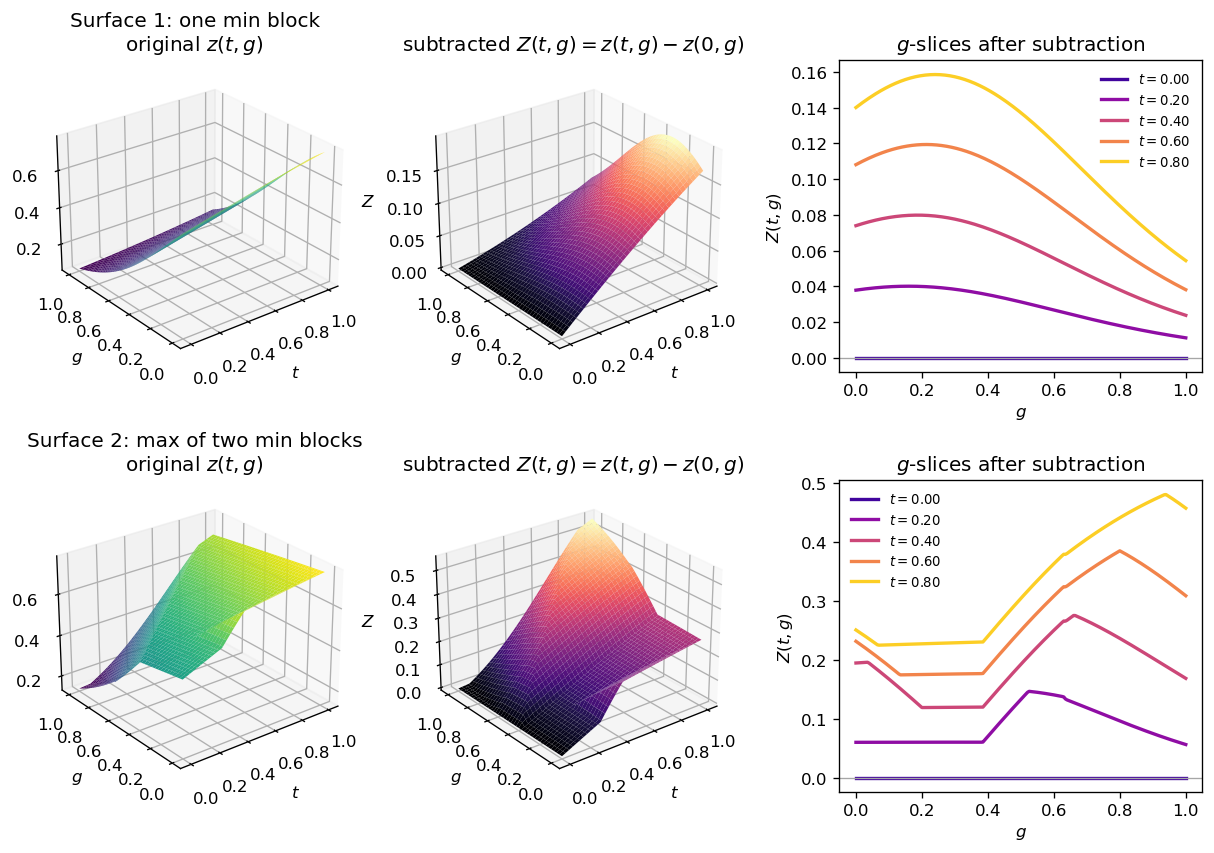

In [4]:
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
selected_t = [0.0, 0.2, 0.4, 0.6, 0.8]

for row, (name, spec) in enumerate(examples.items()):
    p, F = spec["p"], spec["F"]
    ax1 = fig.add_subplot(2, 3, 3 * row + 1, projection="3d")
    ax1.plot_surface(T, G, p, cmap=cm.viridis, linewidth=0, antialiased=True)
    ax1.set(title=f"{name}\noriginal $z(t,g)$", xlabel="$t$", ylabel="$g$", zlabel="$z$")
    ax1.view_init(elev=26, azim=-128)

    ax2 = fig.add_subplot(2, 3, 3 * row + 2, projection="3d")
    ax2.plot_surface(T, G, F, cmap=cm.magma, linewidth=0, antialiased=True)
    ax2.set(title="subtracted $Z(t,g)=z(t,g)-z(0,g)$", xlabel="$t$", ylabel="$g$", zlabel="$Z$")
    ax2.view_init(elev=26, azim=-128)

    ax3 = fig.add_subplot(2, 3, 3 * row + 3)
    colors = cm.plasma(np.linspace(0.1, 0.9, len(selected_t)))
    for tt, color in zip(selected_t, colors):
        i = np.abs(t - tt).argmin()
        ax3.plot(g, F[i], color=color, lw=2, label=fr"$t={t[i]:.2f}$")
    ax3.axhline(0, color="0.65", lw=0.8)
    ax3.set(title="$g$-slices after subtraction", xlabel="$g$", ylabel="$Z(t,g)$")
    ax3.legend(frameon=False, fontsize=8)
fig.savefig("surf_mono_violate_minmax.pdf")
plt.show()

## Where the violation comes from

Baseline subtraction compares two $g$-slopes. If the original surface falls more slowly in $g$ at a later time than it does at baseline, subtracting the more steeply falling baseline produces a positive $g$-slope. The next plot displays finite-difference estimates of $\partial F/\partial g$; colored regions are precisely where the desired nonpositive derivative is violated.

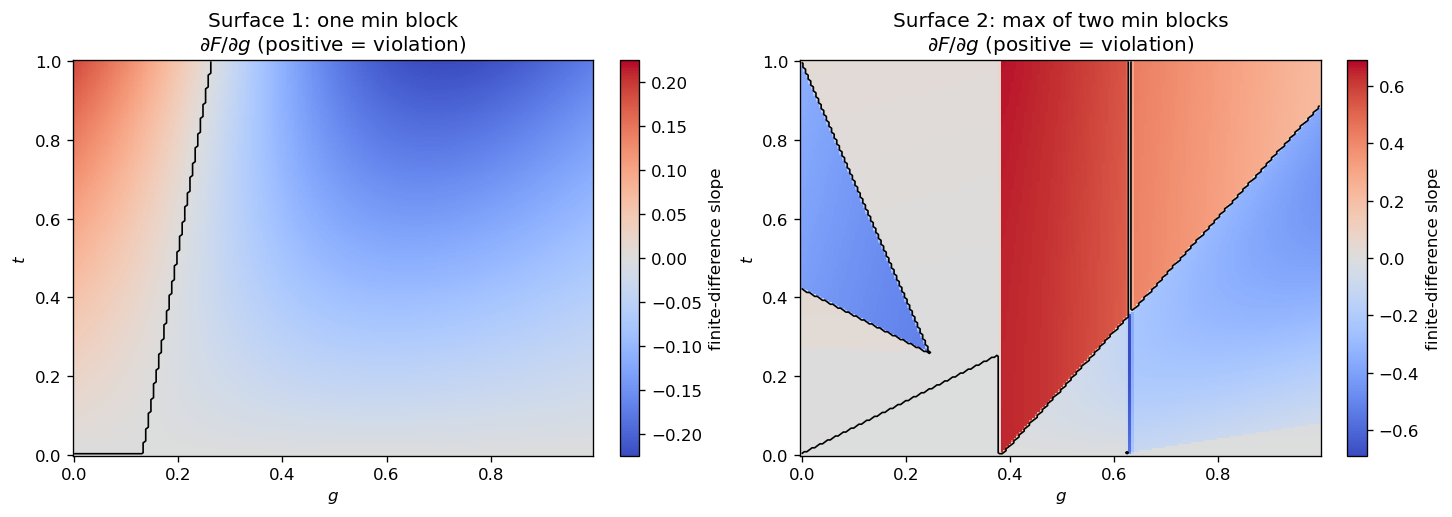

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for ax, (name, spec) in zip(axes, examples.items()):
    dF_dg = np.diff(spec["F"], axis=1) / np.diff(g)[None, :]
    vmax = np.max(np.abs(dF_dg))
    image = ax.pcolormesh(g[:-1], t, dF_dg, shading="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.contour(g[:-1], t, dF_dg > 1e-10, levels=[0.5], colors="black", linewidths=1)
    ax.set(title=name + "\n$\\partial F/\\partial g$ (positive = violation)", xlabel="$g$", ylabel="$t$")
    fig.colorbar(image, ax=ax, label="finite-difference slope")
plt.show()

## The same counterexample with a deep isotonic embedding network

Zhao et al. (2024) propose the **Deep Isotonic Embedding Network (DIEN)**. Its Isotonic Embedding Unit maps each constrained scalar to an ordered vector, and nonnegative downstream weights preserve the specified direction. The construction below is a transparent continuous specialization of that idea, designed to expose the subtraction issue rather than to reproduce the paper's training experiments.

For knots $d_j$, define the ordered ramp embedding

$$e_j(x)=\operatorname{clip}\!\left(\frac{x-d_j}{h},0,1\right).$$

Every component is nondecreasing in $x$. We embed $t$ and $u=1-g$, concatenate their embeddings, and use only nonnegative weights before an increasing sigmoid. Thus the network output is nondecreasing in $t$ and in $u$, equivalently nonincreasing in $g$. All parameters are fixed so that the example remains deterministic.

**Reference:** J. Zhao, H. Zhang, Y. Wang, Y. Zhai, and Y. Yang (2024), “Deep Isotonic Embedding Network: A flexible Monotonic Neural Network,” *Neural Networks* 171, 457–465, https://doi.org/10.1016/j.neunet.2023.12.026.

In [6]:
def isotonic_embedding(x, knots, width):
    """Continuous ordered embedding; each final-axis component increases in x."""
    return np.stack([np.clip((x - knot) / width, 0.0, 1.0) for knot in knots], axis=-1)

def dien_surface(t, g, knots, width, t_weight, g_weight, bias):
    """A DIEN specialization with nonnegative weights and u=1-g."""
    e_t = isotonic_embedding(t, knots, width)
    e_g_down = isotonic_embedding(1.0 - g, knots, width)
    assert t_weight >= 0.0 and g_weight >= 0.0
    logit = bias + t_weight * e_t.mean(axis=-1) + g_weight * e_g_down.mean(axis=-1)
    return sigmoid(logit)

dien_knots = np.linspace(0.0, 0.8, 5)
dien_width = 0.2
dien_parameters = {"t_weight": 5.0, "g_weight": 3.0, "bias": -3.0}

p_dien = dien_surface(T, G, dien_knots, dien_width, **dien_parameters)
baseline_dien = dien_surface(0.0, g, dien_knots, dien_width, **dien_parameters)
F_dien = p_dien - baseline_dien[None, :]

dien_diagnostics = {
    "min delta_t p": np.diff(p_dien, axis=0).min(),
    "max delta_g p": np.diff(p_dien, axis=1).max(),
    "min delta_t F": np.diff(F_dien, axis=0).min(),
    "max delta_g F": np.diff(F_dien, axis=1).max(),
    "max |F(0,g)|": np.abs(F_dien[0]).max(),
}
for quantity, value in dien_diagnostics.items():
    print(f"{quantity:18s}: {value: .3e}")

assert dien_diagnostics["min delta_t p"] >= -1e-12
assert dien_diagnostics["max delta_g p"] <= 1e-12
assert dien_diagnostics["min delta_t F"] >= -1e-12
assert dien_diagnostics["max delta_g F"] > 1e-5
assert dien_diagnostics["max |F(0,g)|"] <= 1e-12

min delta_t p     :  1.683e-04
max delta_g p     : -1.005e-04
min delta_t F     :  1.683e-04
max delta_g F     :  3.649e-03
max |F(0,g)|      :  0.000e+00


The signs in the diagnostics have the same interpretation as before: the original DIEN surface passes both monotonicity checks, whereas the positive `max delta_g F` proves that baseline subtraction breaks the required decrease in $g$.

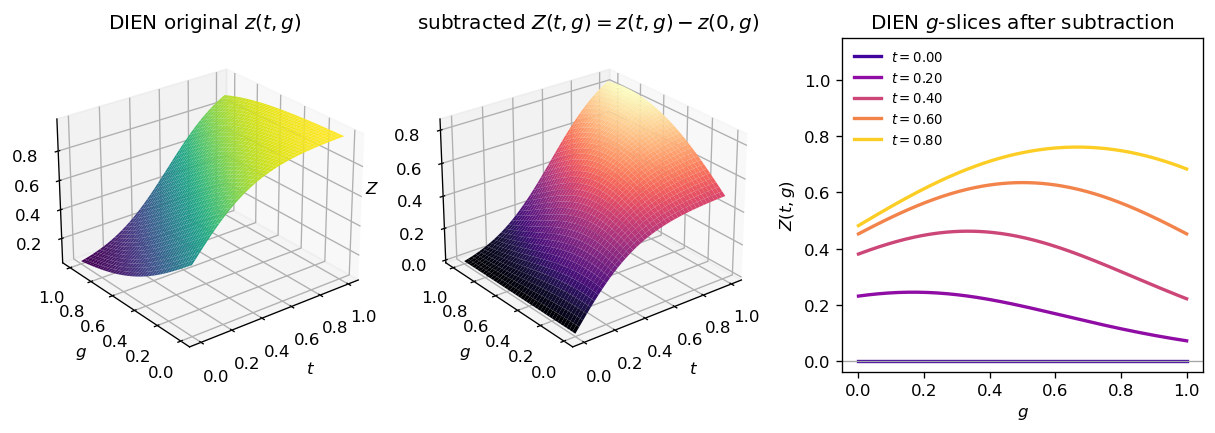

In [7]:
fig = plt.figure(figsize=(10, 3.5), constrained_layout=True)

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(T, G, p_dien, cmap=cm.viridis, linewidth=0, antialiased=True)
ax1.set(title="DIEN original $z(t,g)$", xlabel="$t$", ylabel="$g$", zlabel="$z$")
ax1.view_init(elev=26, azim=-128)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(T, G, F_dien, cmap=cm.magma, linewidth=0, antialiased=True)
ax2.set(title="subtracted $Z(t,g)=z(t,g)-z(0,g)$", xlabel="$t$", ylabel="$g$", zlabel="$Z$")
ax2.view_init(elev=26, azim=-128)

ax3 = fig.add_subplot(1, 3, 3)
colors = cm.plasma(np.linspace(0.1, 0.9, len(selected_t)))
for tt, color in zip(selected_t, colors):
    i = np.abs(t - tt).argmin()
    ax3.plot(g, F_dien[i], color=color, lw=2, label=fr"$t={t[i]:.2f}$")
ax3.axhline(0, color="0.65", lw=0.8)
ax3.set(title="DIEN $g$-slices after subtraction", xlabel="$g$", ylabel="$Z(t,g)$", ylim=(None, 1.15))
ax3.legend(frameon=False, fontsize=8, loc='upper left')
fig.savefig("surf_mono_violate_isotonic_embedding.pdf")
plt.show()

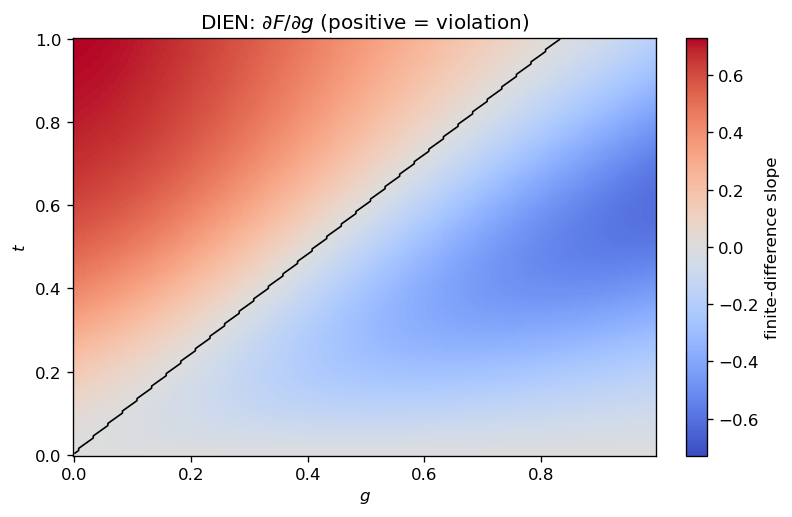

In [8]:
dF_dg_dien = np.diff(F_dien, axis=1) / np.diff(g)[None, :]
vmax = np.max(np.abs(dF_dg_dien))
fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
image = ax.pcolormesh(
    g[:-1], t, dF_dg_dien, shading="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax
)
ax.contour(g[:-1], t, dF_dg_dien > 1e-10, levels=[0.5], colors="black", linewidths=1)
ax.set(
    title="DIEN: $\\partial F/\\partial g$ (positive = violation)",
    xlabel="$g$",
    ylabel="$t$",
)
fig.colorbar(image, ax=ax, label="finite-difference slope")
plt.show()

## Take-away

Coordinate-wise monotonicity of $p$ alone is insufficient. A sufficient additional condition for the subtraction construction would be

$$\frac{\partial p}{\partial g}(t,g)\leq \frac{\partial p}{\partial g}(0,g)$$

at every $(t,g)$ (with the inequality direction chosen so that $F$ remains decreasing in $g$). Ordinary partially monotone architectures do not enforce this cross-time ordering of $g$-slopes. In a cumulative-incidence or survival-surface model, the zero-at-baseline property therefore needs to be built into a parameterization that jointly preserves all required shape constraints, rather than imposed by unrestricted post-hoc subtraction.